# 17 - Purification Policy Comparison

## Objetivo
Comparar as duas políticas de purificação realmente implementadas -
`NeverPurify` (nunca purifica) e `PurifyUntilTarget` (purifica só quando
necessário e permitido) - variando o requisito de fidelidade em poucos
valores, sobre a mesma topologia `a - r - b`.

## Conceitos
- `NeverPurify`/`PurifyUntilTarget` são as únicas duas
  `PurificationStrategy` desta versão (`planning/purification.py`) - não
  há uma terceira implementação real, então este notebook não inventa
  uma.
- `PurifyUntilTarget` só tenta purificar quando o swap isolado fica abaixo
  de `min_fidelity` **e** `intent.policy.allow_purification` é `True`;
  estima um único round analítico via `BBPSSWCircuit.improved_fidelity`
  (`sequence.entanglement_management.purification`) - SeQUeNCe não expõe
  controle do número de rounds (só `purification_mode='until_target'`),
  então mesmo essa política tem um teto de fidelidade alcançável nesta
  versão.
- Nesta topologia (`raw_fidelity=0.85`, `swapping_degradation=0.95`), o
  swap isolado estima ~0.6864 e um round de purificação leva a ~0.7203 -
  um teto real, não configurável.


## Configuração


In [1]:
from ibqn.demos.topologies import three_node_spec
from ibqn.demos.intents import simple_intent
from ibqn.demos.planning import compare_purification_policies
from ibqn.planning.purification import NeverPurify, PurifyUntilTarget

SEED = 0
spec = three_node_spec(stop_time_s=0.2)

# 0.65: below the swap-only estimate (~0.6864) - purification never needed.
# 0.70, 0.72: above swap-only but below the one-round purified estimate
#             (~0.7203) - purification is required and sufficient.
# 0.85: above even the purified estimate - no single-round policy can reach it.
FIDELITY_TARGETS = [0.65, 0.70, 0.72, 0.85]

def make_intent(target):
    return simple_intent(
        intent_id=f"purif-target-{target}", source="a", destination="b",
        min_fidelity=target, requested_pairs=10, duration=0.1,
    )

policies = {"NeverPurify": NeverPurify(), "PurifyUntilTarget": PurifyUntilTarget()}


## Execução


In [2]:
comparison_df = compare_purification_policies(spec, make_intent, policies, FIDELITY_TARGETS, seed=SEED)
comparison_df


2026-07-11 16:04:09,757 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.65 - planned route a->r->b, estimated_fidelity=0.6864, purification=False


2026-07-11 16:04:09,764 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 3 routers, 2 quantum links, seed=0


2026-07-11 16:04:09,765 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.65 - planned route a->r->b, estimated_fidelity=0.6864, purification=False


2026-07-11 16:04:09,765 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.65 - intent registered


2026-07-11 16:04:09,766 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.65 - intent transitioned to VALIDATED (schema validated)


...

2026-07-11 16:04:19,512 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.72 - intent transitioned to ACTIVE (reservation approved)


2026-07-11 16:04:22,548 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.72 - intent transitioned to SATISFIED (all success conditions met)


2026-07-11 16:04:22,551 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.85 - planning failed: no candidate route is feasible: a->r->b (min_fidelity 0.850 exceeds the achievable estimate 0.686 (never-purify baseline strategy))


2026-07-11 16:04:22,552 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.85 - planning failed: no candidate route is feasible: a->r->b (min_fidelity 0.850 exceeds the achievable estimate 0.720 (one-round static estimate (BBPSSWCircuit.improved_fidelity); SeQUeNCe's 'until_target' mode may run a different number of rounds at execution time))


,min_fidelity,policy,requires_purification,estimated_fidelity,feasible,final_status,observed_delivered_pairs,observed_average_fidelity
0,0.65,NeverPurify,False,0.6864,True,SATISFIED,504.0,0.6864
1,0.65,PurifyUntilTarget,False,0.6864,True,SATISFIED,504.0,0.6864
2,0.70,NeverPurify,False,NaN,False,REJECTED,NaN,NaN
3,0.70,PurifyUntilTarget,True,0.7203,True,SATISFIED,128.0,0.7203
4,0.72,NeverPurify,False,NaN,False,REJECTED,NaN,NaN
5,0.72,PurifyUntilTarget,True,0.7203,True,SATISFIED,128.0,0.7203
6,0.85,NeverPurify,False,NaN,False,REJECTED,NaN,NaN
7,0.85,PurifyUntilTarget,False,NaN,False,REJECTED,NaN,NaN


## Resultados


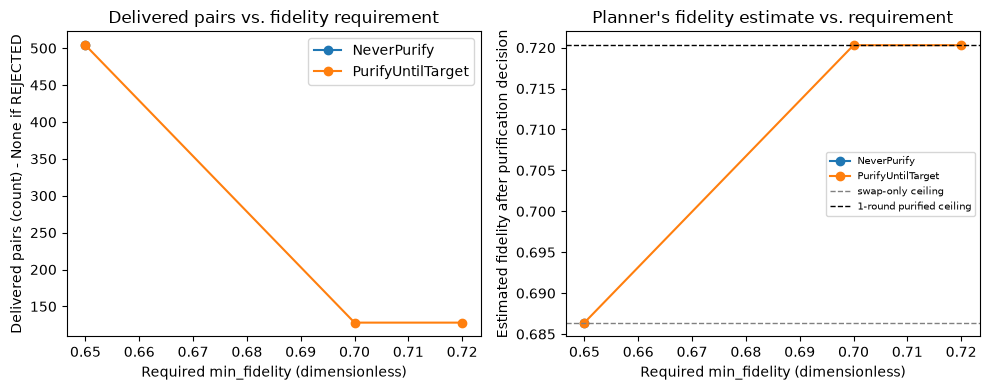

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for policy_name in policies:
    subset = comparison_df[comparison_df["policy"] == policy_name]
    axes[0].plot(subset["min_fidelity"], subset["observed_delivered_pairs"], marker="o", label=policy_name)
    axes[1].plot(subset["min_fidelity"], subset["estimated_fidelity"], marker="o", label=policy_name)

axes[0].set_xlabel("Required min_fidelity (dimensionless)")
axes[0].set_ylabel("Delivered pairs (count) - None if REJECTED")
axes[0].set_title("Delivered pairs vs. fidelity requirement")
axes[0].legend()

axes[1].set_xlabel("Required min_fidelity (dimensionless)")
axes[1].set_ylabel("Estimated fidelity after purification decision")
axes[1].set_title("Planner's fidelity estimate vs. requirement")
axes[1].axhline(0.6864, color="gray", linestyle="--", linewidth=1, label="swap-only ceiling")
axes[1].axhline(0.7203, color="black", linestyle="--", linewidth=1, label="1-round purified ceiling")
axes[1].legend(fontsize=7)

fig.tight_layout()
plt.show()


In [4]:
never_070 = comparison_df[(comparison_df["min_fidelity"] == 0.70) & (comparison_df["policy"] == "NeverPurify")].iloc[0]
purify_070 = comparison_df[(comparison_df["min_fidelity"] == 0.70) & (comparison_df["policy"] == "PurifyUntilTarget")].iloc[0]
assert bool(never_070["feasible"]) is False, "NeverPurify must be rejected at 0.70 (above the swap-only ceiling)"
assert bool(purify_070["feasible"]) is True and bool(purify_070["requires_purification"]) is True

purify_085 = comparison_df[(comparison_df["min_fidelity"] == 0.85) & (comparison_df["policy"] == "PurifyUntilTarget")].iloc[0]
assert bool(purify_085["feasible"]) is False, "even PurifyUntilTarget must be rejected above the 1-round purified ceiling"

satisfied_rows = comparison_df[comparison_df["feasible"]]
assert (satisfied_rows["observed_delivered_pairs"] >= 0).all()
print("Confirmed: purification extends the feasible fidelity range, but only up to its own one-round ceiling.")


Confirmed: purification extends the feasible fidelity range, but only up to its own one-round ceiling.


## Interpretação
Em 0.65, as duas políticas são idênticas (o swap isolado já basta, então
`PurifyUntilTarget` não faz nada diferente de `NeverPurify`). Em 0.70 e
0.72, `NeverPurify` é rejeitado antes de tocar o SeQUeNCe (`REJECTED`),
enquanto `PurifyUntilTarget` aciona um round de purificação e entrega o
intent com sucesso - ao custo de menos pares entregues no mesmo tempo
(purificação consome duas vezes mais pares brutos por par purificado
entregue). Em 0.85, **nenhuma das duas políticas** consegue satisfazer o
requisito: mesmo purificando, a estimativa de um único round
(`BBPSSWCircuit.improved_fidelity`, ~0.7203) fica abaixo do teto exigido -
purificação melhora fidelidade, mas não é ilimitada nesta versão, porque
o número de rounds não é uma decisão configurável (SeQUeNCe só expõe o
modo `'until_target'`, que decide sozinho quantas tentativas fazer em
tempo de execução).

## Limitações
- Não existe uma terceira política de purificação real nesta versão -
  esta comparação é binária por construção, não por escolha editorial.
- A estimativa de "1 round" é apenas isso, uma estimativa: o modo
  `'until_target'` do SeQUeNCe pode (e frequentemente faz) mais de uma
  tentativa em tempo de execução; o número real de rounds não é observado
  diretamente por este notebook (ver notebook 05 do H1, que mostra a
  transição de estado `PURIFIED` real via `MemoryLifecycleRecorder`).

## Conclusão
Purificação demonstrada como uma decisão automática e limitada: expande a
faixa de fidelidade alcançável em relação a nunca purificar, mas tem um
teto real e não configurável nesta versão do planner.
